In [1]:
print(1)

1


In [2]:
import torch
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Số lượng GPU: {torch.cuda.device_count()}")
else:
    print("Không tìm thấy GPU. Hãy kiểm tra cài đặt Settings.")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Số lượng GPU: 1


In [3]:
!nvidia-smi

Sun May 24 01:20:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             47W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
import polars as pl
from pathlib import Path

In [8]:
import os
data_path="/kaggle/input/datasets/organizations/otto/recsys-dataset"
print(os.listdir(data_path))

['otto-recsys-train.jsonl', 'otto-recsys-test.jsonl']


In [9]:
# Đọc file test (hoặc train) và bung dữ liệu lồng nhau thành dạng bảng phẳng
df_train = pl.read_ndjson(f"{data_path}/otto-recsys-train.jsonl")
# df_test = pl.read_ndjson(f"{data_path}/test.jsonl")

In [10]:
# Giải nén cột 'events' để đưa về dạng bảng chuẩn
df_train = df_train.explode("events").unnest("events")
# df_test=df_test.explode("events").unnest("events")

print(df_train.head())

shape: (5, 4)
┌─────────┬─────────┬───────────────┬────────┐
│ session ┆ aid     ┆ ts            ┆ type   │
│ ---     ┆ ---     ┆ ---           ┆ ---    │
│ i64     ┆ i64     ┆ i64           ┆ str    │
╞═════════╪═════════╪═══════════════╪════════╡
│ 0       ┆ 1517085 ┆ 1659304800025 ┆ clicks │
│ 0       ┆ 1563459 ┆ 1659304904511 ┆ clicks │
│ 0       ┆ 1309446 ┆ 1659367439426 ┆ clicks │
│ 0       ┆ 16246   ┆ 1659367719997 ┆ clicks │
│ 0       ┆ 1781822 ┆ 1659367871344 ┆ clicks │
└─────────┴─────────┴───────────────┴────────┘


In [11]:
df_train.columns

['session', 'aid', 'ts', 'type']

In [ ]:
#Kiểm tra xem train và test có session nào trùng ko : session tồn tại ở cả tập train và tập test.
import polars as pl

# 1. Lấy danh sách session duy nhất của từng bộ dưới dạng Series
train_sessions = df_train["session"].unique()
# test_sessions = df_test["session"].unique()

# 2. Tìm các session xuất hiện ở CẢ HAI bộ dữ liệu (Giao nhau)
# Chuyển sang tập hợp (set) của Python để tính toán giao nhau nhanh nhất
# trung_sessions = set(train_sessions).intersection(set(test_sessions))

# 3. In kết quả kiểm tra
print("=" * 60)
print("KIỂM TRA TRÙNG LẶP ID SESSION GIỮA TRAIN VÀ TEST")
print("=" * 60)
print(f"Số lượng session duy nhất trong TRAIN: {len(train_sessions):,}")
print(f"Số lượng session duy nhất trong TEST:  {len(test_sessions):,}")
print("-" * 60)
print(f"SỐ LƯỢNG SESSION BỊ TRÙNG LẶP GIỮA HAI BỘ: {len(trung_sessions):,}")
print("=" * 60)

# Nếu có trùng, in thử ra 5 ID đầu tiên để quan sát
if len(trung_sessions) == 0:
    print("Không có session nào bị trùng giữa TRAIN và TEST.")
else:
    print(f"Có {len(trung_sessions):,} session bị trùng giữa TRAIN và TEST.")
    print(f"Danh sach cac session bi trung: {list(trung_sessions)[:5]}")

KIỂM TRA TRÙNG LẶP ID SESSION GIỮA TRAIN VÀ TEST
Số lượng session duy nhất trong TRAIN: 12,899,779
Số lượng session duy nhất trong TEST:  1,671,803
------------------------------------------------------------
SỐ LƯỢNG SESSION BỊ TRÙNG LẶP GIỮA HAI BỘ: 0
Không có session nào bị trùng giữa TRAIN và TEST.


In [12]:
# 1. Chuyển đổi timestamp và trích xuất giờ, ngày trong tuần
# Unix Timestamp (Epoch Time)
'''
Trong hệ thống máy tính, việc lưu trữ ngày tháng dưới dạng chữ 
(ví dụ: "2026-05-23 10:35:00") rất tốn bộ nhớ và khó tính toán (ví dụ như khi muốn cộng, trừ thời gian).

Vì vậy, các hệ thống thường quy đổi thời gian thành một con số duy nhất. 
Con số này chính là tổng số giây (hoặc mili giây) trôi qua kể từ mốc thời gian gốc
 là 00:00:00 ngày 01 tháng 01 năm 1970 UTC (gọi là thời điểm Epoch).
'''
df_flat_train = df_train.with_columns(
    [
        # Chuyển ts (mili giây) sang kiểu Datetime
        pl.from_epoch("ts", time_unit="ms").alias("timestamp"),
        # Trích xuất giờ (0 - 23)
        pl.from_epoch("ts", time_unit="ms").dt.hour().alias("hour"),
        # Trích xuất ngày trong tuần (1 = Thứ 2, 7 = Chủ Nhật)
        pl.from_epoch("ts", time_unit="ms").dt.weekday().alias("day_of_week"),
    ]
)
# df_flat_test = df_test.with_columns(
#     [
#         # Chuyển ts (mili giây) Dang Unix  sang kiểu Datetime
#         pl.from_epoch("ts", time_unit="ms").alias("timestamp"),
#         # Trích xuất giờ (0 - 23)
#         pl.from_epoch("ts", time_unit="ms").dt.hour().alias("hour"),
#         # Trích xuất ngày trong tuần (1 = Thứ 2, 7 = Chủ Nhật)
#         pl.from_epoch("ts", time_unit="ms").dt.weekday().alias("day_of_week"),
#     ]
# )
# 2. Không cần cache() chủ động vì Polars tối ưu hóa bộ nhớ rất tốt
# (Nếu bạn dùng LazyFrame, bạn chỉ cần gọi .collect() để thực thi)

# 3. Hiển thị 5 dòng đầu tiên
print(df_flat_train.head(5))
# print(df_flat_test.head(5))

shape: (5, 7)
┌─────────┬─────────┬───────────────┬────────┬─────────────────────────┬──────┬─────────────┐
│ session ┆ aid     ┆ ts            ┆ type   ┆ timestamp               ┆ hour ┆ day_of_week │
│ ---     ┆ ---     ┆ ---           ┆ ---    ┆ ---                     ┆ ---  ┆ ---         │
│ i64     ┆ i64     ┆ i64           ┆ str    ┆ datetime[ms]            ┆ i8   ┆ i8          │
╞═════════╪═════════╪═══════════════╪════════╪═════════════════════════╪══════╪═════════════╡
│ 0       ┆ 1517085 ┆ 1659304800025 ┆ clicks ┆ 2022-07-31 22:00:00.025 ┆ 22   ┆ 7           │
│ 0       ┆ 1563459 ┆ 1659304904511 ┆ clicks ┆ 2022-07-31 22:01:44.511 ┆ 22   ┆ 7           │
│ 0       ┆ 1309446 ┆ 1659367439426 ┆ clicks ┆ 2022-08-01 15:23:59.426 ┆ 15   ┆ 1           │
│ 0       ┆ 16246   ┆ 1659367719997 ┆ clicks ┆ 2022-08-01 15:28:39.997 ┆ 15   ┆ 1           │
│ 0       ┆ 1781822 ┆ 1659367871344 ┆ clicks ┆ 2022-08-01 15:31:11.344 ┆ 15   ┆ 1           │
└─────────┴─────────┴───────────────┴────────┴

In [10]:
pl.Config.set_tbl_rows(20)

# =====================================================================
# 1. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TRAIN
# =====================================================================
train_aid_counts = (
    df_flat_train.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 2. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TEST
# =====================================================================
test_aid_counts = (
    df_flat_test.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 3. TÍNH TỔNG SỐ LƯỢNG SẢN PHẨM DUY NHẤT (UNIQUE ITEMS)
# =====================================================================
tong_aid_train = train_aid_counts.height
tong_aid_test = test_aid_counts.height

# Tính số sản phẩm xuất hiện ở cả 2 bộ (Giao nhau)
giao_aid = len(set(train_aid_counts["aid"]).intersection(set(test_aid_counts["aid"])))

# =====================================================================
# 4. IN KẾT QUẢ THỐNG KÊ TỔNG QUAN
# =====================================================================
print("=" * 60)
print("THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST")
print("=" * 60)
print(f"Tổng số sản phẩm duy nhất trong bộ TRAIN: {tong_aid_train:,}")
print(f"Tổng số sản phẩm duy nhất trong bộ TEST:  {tong_aid_test:,}")
print(f"Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: {giao_aid:,}")
print(f"-> Tỷ lệ bao phủ (Coverage): {(giao_aid / tong_aid_test) * 100:.2f}%")
print("-" * 60)

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:")
print(train_aid_counts.head(5))

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:")
print(test_aid_counts.head(5))
print("=" * 60)

THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST
Tổng số sản phẩm duy nhất trong bộ TRAIN: 1,855,603
Tổng số sản phẩm duy nhất trong bộ TEST:  783,486
Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: 783,486
-> Tỷ lệ bao phủ (Coverage): 100.00%
------------------------------------------------------------

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 1460571 ┆ 129004            │
│ 485256  ┆ 126836            │
│ 108125  ┆ 118524            │
│ 29735   ┆ 113279            │
│ 1733943 ┆ 105091            │
└─────────┴───────────────────┘

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 485256  ┆ 9056              │
│ 1460571 ┆ 8870  

In [11]:
#Lưu danh sách sản phẩm của tập train và test ra file để tái sử dụng về sau .
print("Đang tiến hành xuất danh sách sản phẩm ra file CSV...")

# Lọc chỉ lấy cột 'aid' và ghi ra file
train_aid_counts.select("aid").write_csv("train_aids.csv", include_header=True)
test_aid_counts.select("aid").write_csv("test_aids.csv", include_header=True)

print("=" * 60)
print("ĐÃ LƯU THÀNH CÔNG!")
print("- Danh sách AID Train: train_aids.csv")
print("- Danh sách AID Test:  test_aids.csv")
print("=" * 60)

Đang tiến hành xuất danh sách sản phẩm ra file CSV...
ĐÃ LƯU THÀNH CÔNG!
- Danh sách AID Train: train_aids.csv
- Danh sách AID Test:  test_aids.csv


In [ ]:
# # Đọc lại danh sách sản phẩm từ file CSV
# train_aids = pl.read_csv("train_aids.csv")
# test_aids = pl.read_csv("test_aids.csv")

# # Kiểm tra thử dữ liệu vừa nạp
# print("Dữ liệu Train AID nạp lại:")
# print(train_aids.height)

Dữ liệu Train AID nạp lại:
1855603


In [ ]:
#Đối với những sản phẩm chưa thấy bao giờ, kiểu xuất hiện trong tập test mà không xuất hiện trong tập train ấy
#thì phải xử lí cold start.

In [10]:
# Lọc ra ngày đầu tiên và ngày cuối cùng trong mốc thời gian
thoi_gian_min_max_train = df_flat_train.select(
    [
        pl.col("timestamp").min().alias("ngay_dau_tien"),
        pl.col("timestamp").max().alias("ngay_cuoi_cung"),
    ]
)
# thoi_gian_min_max_test = df_flat_test.select(
#     [
#         pl.col("timestamp").min().alias("ngay_dau_tien"),
#         pl.col("timestamp").max().alias("ngay_cuoi_cung"),
#     ]
# )
print(thoi_gian_min_max_train)

shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ ngay_dau_tien           ┆ ngay_cuoi_cung          │
│ ---                     ┆ ---                     │
│ datetime[ms]            ┆ datetime[ms]            │
╞═════════════════════════╪═════════════════════════╡
│ 2022-07-31 22:00:00.025 ┆ 2022-08-28 21:59:59.984 │
└─────────────────────────┴─────────────────────────┘


dữ liệu Train này kéo dài chính xác trong vòng 4 tuần (28 ngày).
Tuần 1: 31/07/2022 (Chủ Nhật) – 07/08/2022 (Chủ Nhật)

Tuần 2: 07/08/2022 (Chủ Nhật) – 14/08/2022 (Chủ Nhật)

Tuần 3: 14/08/2022 (Chủ Nhật) – 21/08/2022 (Chủ Nhật)

Tuần 4: 21/08/2022 (Chủ Nhật) – 28/08/2022 (Chủ Nhật)
Vì múi giờ gốc của dữ liệu được tính theo giờ UTC, nhưng khi quy đổi chính xác, họ luôn cắt dữ liệu vào đúng thời điểm giao tuần để đảm bảo tính chu kỳ.

In [ ]:
# print(thoi_gian_min_max_test)

shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ ngay_dau_tien           ┆ ngay_cuoi_cung          │
│ ---                     ┆ ---                     │
│ datetime[ms]            ┆ datetime[ms]            │
╞═════════════════════════╪═════════════════════════╡
│ 2022-08-28 22:00:00.278 ┆ 2022-09-04 21:59:51.563 │
└─────────────────────────┴─────────────────────────┘


In [11]:
#Xu li train bo train
# Tính số ngày trôi qua kể từ ngày đầu tiên, rồi chia cho 7 để ra số tuần (1, 2, 3, 4)
ngay_dau_tien = pl.datetime(2022, 7, 31, 22, 0, 0)

df_flat_train = df_flat_train.with_columns(
    (
        ((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1
    ).alias("thu_tu_tuan")
)

# Thử kiểm tra xem mỗi tuần có bao nhiêu tương tác
print(df_flat_train["thu_tu_tuan"].value_counts())

shape: (4, 2)
┌─────────────┬──────────┐
│ thu_tu_tuan ┆ count    │
│ ---         ┆ ---      │
│ i64         ┆ u32      │
╞═════════════╪══════════╡
│ 2           ┆ 55387191 │
│ 3           ┆ 55407112 │
│ 1           ┆ 53160878 │
│ 4           ┆ 52760915 │
└─────────────┴──────────┘


In [12]:
df_flat_train.filter(pl.col("thu_tu_tuan") == 4)

session,aid,ts,type,timestamp,hour,day_of_week,thu_tu_tuan
i64,i64,i64,str,datetime[ms],i8,i8,i64
0,10268,1661157951797,"""clicks""",2022-08-22 08:45:51.797,8,1,4
0,219925,1661157962188,"""clicks""",2022-08-22 08:46:02.188,8,1,4
0,1140855,1661157993281,"""clicks""",2022-08-22 08:46:33.281,8,1,4
0,915702,1661158034888,"""clicks""",2022-08-22 08:47:14.888,8,1,4
0,480578,1661158090652,"""clicks""",2022-08-22 08:48:10.652,8,1,4
…,…,…,…,…,…,…,…
12899776,1737908,1661723987073,"""clicks""",2022-08-28 21:59:47.073,21,7,4
12899777,384045,1661723976974,"""clicks""",2022-08-28 21:59:36.974,21,7,4
12899777,384045,1661723986800,"""clicks""",2022-08-28 21:59:46.800,21,7,4


In [13]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

/tmp/ipykernel_57/4037329559.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  type_counts = df_flat_train.group_by("type").count()


shape: (3, 2)
┌────────┬───────────┐
│ type   ┆ count     │
│ ---    ┆ ---       │
│ str    ┆ u32       │
╞════════╪═══════════╡
│ clicks ┆ 194720954 │
│ carts  ┆ 16896191  │
│ orders ┆ 5098951   │
└────────┴───────────┘


/tmp/ipykernel_57/4037329559.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="type", y="count", palette="Blues_r")


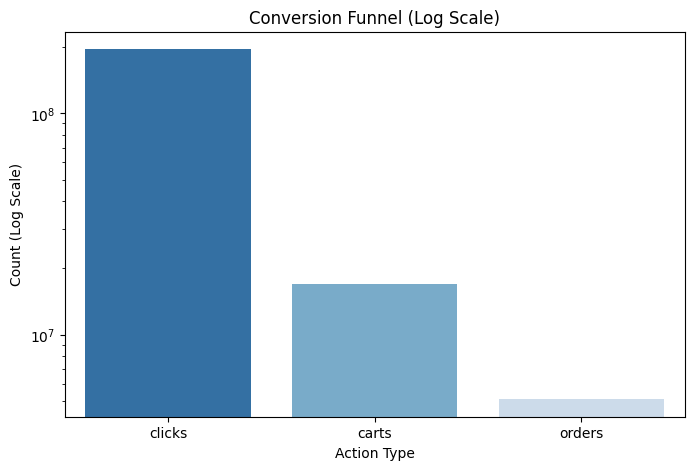

In [14]:
# 1. THỐNG KÊ SỐ LƯỢNG THEO LOẠI HÀNH ĐỘNG
type_counts = df_flat_train.group_by("type").count()
print(type_counts)

# Chuyển sang Pandas CHỈ ở bước cuối cùng để phục vụ việc vẽ đồ thị Matplotlib/Seaborn
df_plot = type_counts.to_pandas()


plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x="type", y="count", palette="Blues_r")

# Dùng thang đo Log vì lượng 'clicks' thường áp đảo hoàn toàn so với 'orders'
plt.yscale("log")
plt.title("Conversion Funnel (Log Scale)")
plt.xlabel("Action Type")
plt.ylabel("Count (Log Scale)")
plt.show()


In [15]:
#Cac thong ke lien quan den phien
#So luong phien của tap train/test
session_count=[df_flat_train["session"].n_unique(), df_flat_test["session"].n_unique()]
print(session_count)

[12899779, 1671803]


In [16]:
# Với mỗi session, ta tính:
# - so_tuong_tac: Số lượng hành động (độ dài phiên)
# - thoi_gian_dau: Thời điểm tương tác đầu tiên trong phiên
# - thoi_gian_cuoi: Thời điểm tương tác cuối cùng trong phiên
session_stats = df_flat_train.group_by("session").agg(
    [
        pl.len().alias("so_tuong_tac"),
        pl.col("timestamp").min().alias("thoi_gian_dau"),
        pl.col("timestamp").max().alias("thoi_gian_cuoi"),
    ]
)
print(session_stats.head(10))

shape: (10, 4)
┌──────────┬──────────────┬─────────────────────────┬─────────────────────────┐
│ session  ┆ so_tuong_tac ┆ thoi_gian_dau           ┆ thoi_gian_cuoi          │
│ ---      ┆ ---          ┆ ---                     ┆ ---                     │
│ i64      ┆ u32          ┆ datetime[ms]            ┆ datetime[ms]            │
╞══════════╪══════════════╪═════════════════════════╪═════════════════════════╡
│ 8975965  ┆ 4            ┆ 2022-08-15 17:05:27.986 ┆ 2022-08-15 17:11:19.394 │
│ 8375152  ┆ 5            ┆ 2022-08-14 14:08:20.078 ┆ 2022-08-16 12:46:09.705 │
│ 1321826  ┆ 49           ┆ 2022-08-02 05:49:33.330 ┆ 2022-08-27 22:47:48.639 │
│ 11959352 ┆ 18           ┆ 2022-08-25 07:36:01.832 ┆ 2022-08-27 16:40:41.876 │
│ 1793187  ┆ 97           ┆ 2022-08-02 15:45:12.723 ┆ 2022-08-28 13:38:30.743 │
│ 5429017  ┆ 108          ┆ 2022-08-08 08:17:50.743 ┆ 2022-08-08 20:54:09.420 │
│ 11297085 ┆ 3            ┆ 2022-08-22 17:19:27.123 ┆ 2022-08-22 17:22:14.467 │
│ 17787    ┆ 18          

In [17]:
# Tính tổng thời lượng của mỗi phiên (đơn vị: phút)
session_stats = session_stats.with_columns(
    (
        (pl.col("thoi_gian_cuoi") - pl.col("thoi_gian_dau")).dt.total_milliseconds()
        / (1000 * 60)
    ).alias("thoi_luong_phut")
)
print(session_stats.head(10))

shape: (10, 5)
┌──────────┬──────────────┬─────────────────────────┬─────────────────────────┬─────────────────┐
│ session  ┆ so_tuong_tac ┆ thoi_gian_dau           ┆ thoi_gian_cuoi          ┆ thoi_luong_phut │
│ ---      ┆ ---          ┆ ---                     ┆ ---                     ┆ ---             │
│ i64      ┆ u32          ┆ datetime[ms]            ┆ datetime[ms]            ┆ f64             │
╞══════════╪══════════════╪═════════════════════════╪═════════════════════════╪═════════════════╡
│ 8975965  ┆ 4            ┆ 2022-08-15 17:05:27.986 ┆ 2022-08-15 17:11:19.394 ┆ 5.8568          │
│ 8375152  ┆ 5            ┆ 2022-08-14 14:08:20.078 ┆ 2022-08-16 12:46:09.705 ┆ 2797.827117     │
│ 1321826  ┆ 49           ┆ 2022-08-02 05:49:33.330 ┆ 2022-08-27 22:47:48.639 ┆ 37018.25515     │
│ 11959352 ┆ 18           ┆ 2022-08-25 07:36:01.832 ┆ 2022-08-27 16:40:41.876 ┆ 3424.6674       │
│ 1793187  ┆ 97           ┆ 2022-08-02 15:45:12.723 ┆ 2022-08-28 13:38:30.743 ┆ 37313.300333    │
│ 542

In [18]:
# STEP 2: TÍNH TOÁN CÁC CHỈ SỐ THỐNG KÊ TỔNG HỢP

# 1. Tổng số lượng phiên duy nhất
tong_so_phien = session_stats['session'].n_unique()

# 2. Thống kê về độ dài phiên (Số lượng tương tác)
click_max = session_stats["so_tuong_tac"].max()
click_min = session_stats["so_tuong_tac"].min()
click_mean = session_stats["so_tuong_tac"].mean()
click_median = session_stats["so_tuong_tac"].median()

# 3. Thống kê về thời lượng phiên (Phút)
time_max = session_stats["thoi_luong_phut"].max()
time_min = session_stats["thoi_luong_phut"].min()
time_mean = session_stats["thoi_luong_phut"].mean()
time_median = session_stats["thoi_luong_phut"].median()

# STEP 3: IN KẾT QUẢ THỐNG KÊ
print("=" * 50)
print("THỐNG KÊ CHI TIẾT VỀ PHIÊN NGƯỜI DÙNG (SESSION STATS)")
print("=" * 50)
print(f"Tổng số lượng phiên (Sessions): {tong_so_phien:,}")
print("-" * 50)
print("1. Thống kê về độ dài phiên (Số lượng tương tác/hành động):")
print(f"   - Phiên có nhiều tương tác nhất: {click_max:,} tương tác")
print(f"   - Phiên có ít tương tác nhất:   {click_min:,} tương tác")
print(f"   - Số tương tác trung bình (Mean): {click_mean:.2f} tương tác")
print(f"   - Trung vị số tương tác (Median): {click_median:.1f} tương tác")
print("-" * 50)
print("2. Thống kê về thời lượng phiên (Thời gian từ đầu đến cuối phiên):")
print(f"   - Thời lượng phiên dài nhất: {time_max:.2f} phút (~ {time_max/60:.1f} giờ)")
print(f"   - Thời lượng phiên ngắn nhất: {time_min:.2f} phút")
print(f"   - Thời lượng trung bình (Mean): {time_mean:.2f} phút")
print(f"   - Trung vị thời lượng (Median): {time_median:.2f} phút")
print("=" * 50)

THỐNG KÊ CHI TIẾT VỀ PHIÊN NGƯỜI DÙNG (SESSION STATS)
Tổng số lượng phiên (Sessions): 12,899,779
--------------------------------------------------
1. Thống kê về độ dài phiên (Số lượng tương tác/hành động):
   - Phiên có nhiều tương tác nhất: 500 tương tác
   - Phiên có ít tương tác nhất:   2 tương tác
   - Số tương tác trung bình (Mean): 16.80 tương tác
   - Trung vị số tương tác (Median): 6.0 tương tác
--------------------------------------------------
2. Thống kê về thời lượng phiên (Thời gian từ đầu đến cuối phiên):
   - Thời lượng phiên dài nhất: 40319.85 phút (~ 672.0 giờ)
   - Thời lượng phiên ngắn nhất: 0.00 phút
   - Thời lượng trung bình (Mean): 9875.64 phút
   - Trung vị thời lượng (Median): 3093.64 phút


/tmp/ipykernel_149/206320581.py:16: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()
/tmp/ipykernel_149/206320581.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


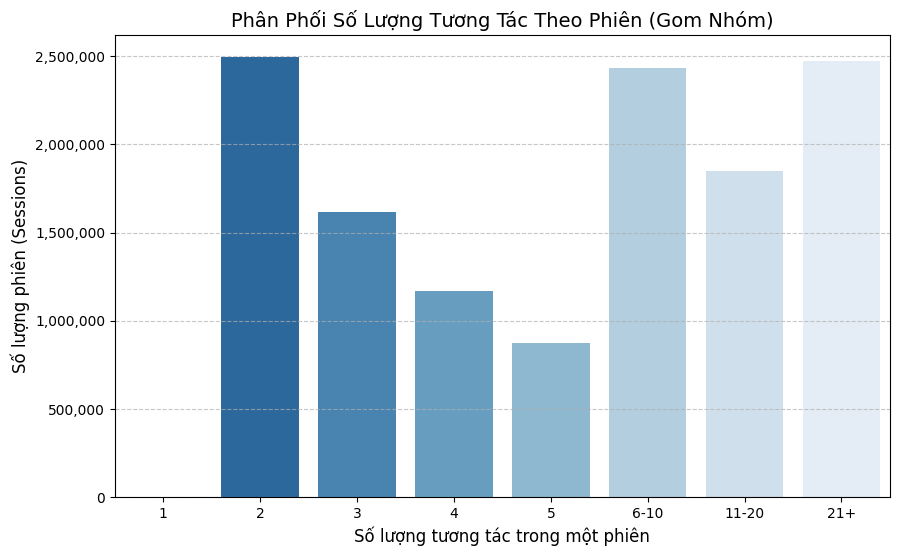

In [19]:
# Tạo điều kiện phân đoạn bằng Polars nhanh chóng
df_bins = session_stats.with_columns(
    pl.when(pl.col("so_tuong_tac") <= 5)
    .then(pl.col("so_tuong_tac").cast(pl.String))
    .when(pl.col("so_tuong_tac") <= 10)
    .then(pl.lit("6-10"))
    .when(pl.col("so_tuong_tac") <= 20)
    .then(pl.lit("11-20"))
    .otherwise(pl.lit("21+"))
    .alias("nhom_tuong_tac")
)

# Đếm số lượng phiên trong từng nhóm
nhom_counts = (
    df_bins.group_by("nhom_tuong_tac")
    .count()
    .sort("count", descending=True)
    .to_pandas()
)

# Định nghĩa thứ tự hiển thị trên trục X cho logic
order = ["1", "2", "3", "4", "5", "6-10", "11-20", "21+"]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    data=nhom_counts,
    x="nhom_tuong_tac",
    y="count",
    order=order,
    palette="Blues_r",
)

plt.title("Phân Phối Số Lượng Tương Tác Theo Phiên (Gom Nhóm)", fontsize=14)
plt.xlabel("Số lượng tương tác trong một phiên", fontsize=12)
plt.ylabel("Số lượng phiên (Sessions)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Định dạng hiển thị số trục Y dạng 1,000,000 cho dễ nhìn
plt.gca().get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)
plt.show()

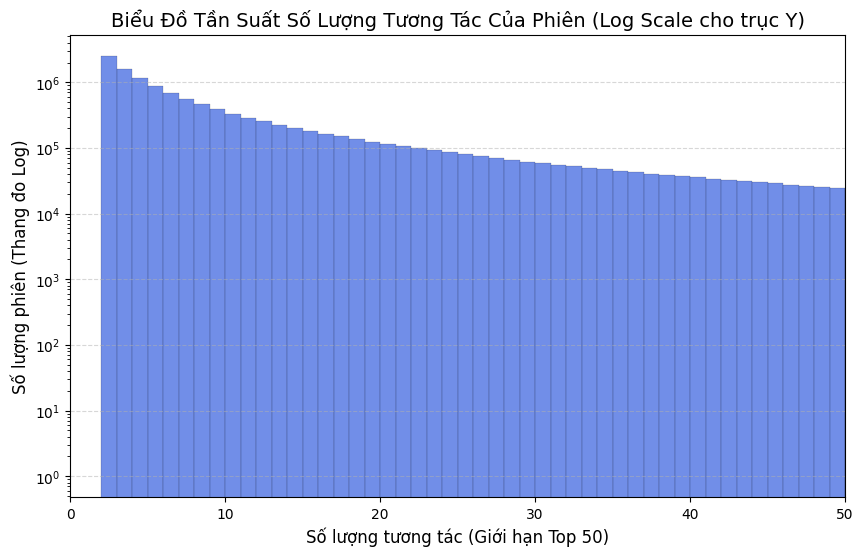

In [20]:
# Chuyển cột số lượng tương tác sang Pandas để vẽ
data_plot = session_stats["so_tuong_tac"].to_pandas()

plt.figure(figsize=(10, 6))
# Sử dụng histplot với binwidth=1 để mỗi cột biểu thị đúng 1 mốc số lượng tương tác
sns.histplot(data_plot, binwidth=1, color="royalblue", kde=False)

# Giới hạn trục X ở mốc 50 tương tác đầu tiên để biểu đồ không bị quá dài ra vô tận
plt.xlim(0, 50)

# Chuyển trục Y sang scale log để thấy được các cột phía sau
plt.yscale("log")

plt.title(
    "Biểu Đồ Tần Suất Số Lượng Tương Tác Của Phiên (Log Scale cho trục Y)",
    fontsize=14,
)
plt.xlabel("Số lượng tương tác (Giới hạn Top 50)", fontsize=12)
plt.ylabel("Số lượng phiên (Thang đo Log)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [21]:
print(df_bins.head(5))

shape: (5, 6)
┌──────────┬──────────────┬───────────────┬────────────────┬─────────────────┬────────────────┐
│ session  ┆ so_tuong_tac ┆ thoi_gian_dau ┆ thoi_gian_cuoi ┆ thoi_luong_phut ┆ nhom_tuong_tac │
│ ---      ┆ ---          ┆ ---           ┆ ---            ┆ ---             ┆ ---            │
│ i64      ┆ u32          ┆ datetime[ms]  ┆ datetime[ms]   ┆ f64             ┆ str            │
╞══════════╪══════════════╪═══════════════╪════════════════╪═════════════════╪════════════════╡
│ 10531499 ┆ 6            ┆ 2022-08-20    ┆ 2022-08-20     ┆ 4.7885          ┆ 6-10           │
│          ┆              ┆ 10:29:30.254  ┆ 10:34:17.564   ┆                 ┆                │
│ 4791985  ┆ 5            ┆ 2022-08-06    ┆ 2022-08-06     ┆ 6.718883        ┆ 5              │
│          ┆              ┆ 21:21:09.891  ┆ 21:27:53.024   ┆                 ┆                │
│ 11231909 ┆ 5            ┆ 2022-08-22    ┆ 2022-08-22     ┆ 2.6975          ┆ 5              │
│          ┆              

In [22]:
print(
    f"Số lượng phiên có ít hơn 5 tương tác: {len(session_stats.filter(pl.col('so_tuong_tac') < 5)):,}"
)
print(
    f"Số lượng phiên có ít hơn 5 tương tác: {session_stats.filter(pl.col('so_tuong_tac') < 5).height:,}"
)

#Ti le phan tram cua cac phien co it hon 5 tuong tac
so_phien_it_hon_5 = session_stats.filter(pl.col("so_tuong_tac") < 5).height
ti_le_it_hon_5 = (so_phien_it_hon_5 / tong_so_phien) * 100
print(f"Tỷ lệ phiên có ít hơn 5 tương tác: {ti_le_it_hon_5:.2f}%")

Số lượng phiên có ít hơn 5 tương tác: 5,275,390
Số lượng phiên có ít hơn 5 tương tác: 5,275,390
Tỷ lệ phiên có ít hơn 5 tương tác: 40.90%


In [19]:
#Kiem tra xem co bao nhieu session co it hon 5 hanh vi ma co 
# Bước 1: Tính tổng số lượng tương tác của từng session từ bảng gốc
session_total_interactions = df_flat_train.group_by("session").agg(
    pl.len().alias("tong_tuong_tac")
)
# Bước 2: Lọc lấy danh sách các ID session có ít hơn 5 tương tác
short_sessions = session_total_interactions.filter(
    pl.col("tong_tuong_tac") < 5
).select("session")
# Bước 3: Lọc dữ liệu gốc để lấy các hành vi 'orders' thuộc về những session ngắn này
# Sau đó đếm số lượng session duy nhất (n_unique)
result_count = (
    df_flat_train.filter(
        (pl.col("type") == "orders")
        & (pl.col("session").is_in(short_sessions["session"]))
    )["session"].n_unique()
)
carts_count = (
    df_flat_train.filter(
        (pl.col("type") == "carts")
        & (pl.col("session").is_in(short_sessions["session"]))
    )["session"].n_unique()
)

print(
    f"Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'orders': {result_count:,}"
)
print(
    f"Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'carts': {carts_count:,}"
)

/tmp/ipykernel_57/275006816.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_flat_train.filter(
/tmp/ipykernel_57/275006816.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_flat_train.filter(


Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'orders': 62,991
Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'carts': 312,748


In [20]:
#Tap train se loai bo di cac session co it hon 5 tuogn tac ma ko co hanh vi 'orders'
# Bước 1: Tính tổng số lượng tương tác của từng session từ bảng gốc
session_total_interactions = df_flat_train.group_by("session").agg(
    pl.len().alias("tong_tuong_tac")
)  
# Bước 2: Lọc lấy danh sách các ID session có ít hơn 5 tương tác
short_sessions = session_total_interactions.filter(
    pl.col("tong_tuong_tac") <5

).select("session")

# Bước 3: Lọc dữ liệu gốc để lấy các session có ít hơn 5 tương tác nhưng vẫn có hành vi 'orders'
sessions_to_remove = (
    df_flat_train.filter(
        (pl.col("type") == "orders")
        & (pl.col("session").is_in(short_sessions["session"]))
    )["session"]
    .n_unique()
)
print(f"Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'orders': {sessions_to_remove:,}"
)


/tmp/ipykernel_57/4191050865.py:14: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_flat_train.filter(


Số lượng session có ít hơn 5 tương tác nhưng vẫn có hành vi 'orders': 62,991


In [13]:
# Bước 1: Thống kê đặc trưng của từng session (Tổng tương tác và có đơn hàng hay không)
session_profiles = df_flat_train.group_by("session").agg(
    [
        pl.len().alias("tong_tuong_tac"),
        # Kiểm tra xem trong cụm session này có bất kỳ dòng nào là 'orders' không (Trả về True/False)
        pl.col("type").eq("orders").any().alias("co_orders"),
    ]
)

# Bước 2: Lọc các session thỏa mãn 1 trong 2 điều kiện của bạn:
# - Điều kiện 1: Có tổng tương tác > 5
# - Điều kiện 2: Có tổng tương tác <= 5 VÀ bắt buộc phải có hành vi 'orders' (co_orders == True)
valid_sessions = session_profiles.filter(
    (pl.col("tong_tuong_tac") > 5)
    | ((pl.col("tong_tuong_tac") <= 5) & pl.col("co_orders"))
).select("session")

# Bước 3: Lọc lại bảng dữ liệu gốc bằng phép Inner Join
# Cách này giúp Polars chạy cực nhanh bằng thuật toán Hash Join và cực kỳ tiết kiệm bộ nhớ so với dùng .is_in()
df_flat_train_filtered = df_flat_train.join(
    valid_sessions, on="session", how="inner"
)

# Kiểm tra thử kết quả dữ liệu sau khi lọc
print(f"Số dòng trước khi lọc: {df_flat_train.height:,}")
print(f"Số dòng sau khi lọc:  {df_flat_train_filtered.height:,}")
print(
    f"Số lượng session còn lại: {df_flat_train_filtered['session'].n_unique():,}"
)

Số dòng trước khi lọc: 216,716,096
Số dòng sau khi lọc:  198,370,098
Số lượng session còn lại: 6,868,678


In [14]:
import gc

# 1. Xóa các biến nặng không dùng nữa
del df_train
del valid_sessions
del session_profiles
del df_flat_train

# 2. Ép hệ thống giải phóng RAM ngay lập tức
gc.collect()

0

In [13]:
pl.Config.set_tbl_rows(50)

# =====================================================================
# 1. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TRAIN
# =====================================================================
train_aid_counts = (
    df_flat_train_filtered.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 2. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TEST
# =====================================================================
test_aid_counts = (
    df_flat_test.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 3. TÍNH TỔNG SỐ LƯỢNG SẢN PHẨM DUY NHẤT (UNIQUE ITEMS)
# =====================================================================
tong_aid_train = train_aid_counts.height
tong_aid_test = test_aid_counts.height

# Tính số sản phẩm xuất hiện ở cả 2 bộ (Giao nhau)
giao_aid = len(set(train_aid_counts["aid"]).intersection(set(test_aid_counts["aid"])))

# =====================================================================
# 4. IN KẾT QUẢ THỐNG KÊ TỔNG QUAN
# =====================================================================
print("=" * 60)
print("THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST")
print("=" * 60)
print(f"Tổng số sản phẩm duy nhất trong bộ TRAIN: {tong_aid_train:,}")
print(f"Tổng số sản phẩm duy nhất trong bộ TEST:  {tong_aid_test:,}")
print(f"Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: {giao_aid:,}")
print(f"-> Tỷ lệ bao phủ (Coverage): {(giao_aid / tong_aid_test) * 100:.2f}%")
print("-" * 60)

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:")
print(train_aid_counts.head(5))

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:")
# print(test_aid_counts.head(5))
print("=" * 60)

THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST
Tổng số sản phẩm duy nhất trong bộ TRAIN: 1,854,462
Tổng số sản phẩm duy nhất trong bộ TEST:  783,486
Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: 783,395
-> Tỷ lệ bao phủ (Coverage): 99.99%
------------------------------------------------------------

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 1460571 ┆ 112020            │
│ 108125  ┆ 106787            │
│ 29735   ┆ 102615            │
│ 485256  ┆ 101306            │
│ 1733943 ┆ 93892             │
└─────────┴───────────────────┘

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:


In [14]:
import gc

# 1. Xóa các biến nặng không dùng nữa
del train_aid_counts


# 2. Ép hệ thống giải phóng RAM ngay lập tức
gc.collect()

0

In [11]:
#Lưu danh sách sản phẩm của tập train và test ra file để tái sử dụng về sau .
print("Đang tiến hành xuất danh sách sản phẩm ra file CSV...")

# Lọc chỉ lấy cột 'aid' và ghi ra file
train_aid_counts.select("aid").write_csv("train_aids_filtered.csv", include_header=True)
print("=" * 60)
print("ĐÃ LƯU THÀNH CÔNG!")
print("- Danh sách AID Train: train_aids_filtered.csv")
print("=" * 60)

Đang tiến hành xuất danh sách sản phẩm ra file CSV...
ĐÃ LƯU THÀNH CÔNG!
- Danh sách AID Train: train_aids_filtered.csv


============================================================
THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST
============================================================
Tổng số sản phẩm duy nhất trong bộ TRAIN: 1,854,462
Tổng số sản phẩm duy nhất trong bộ TEST:  783,486
Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: 783,395
-> Tỷ lệ bao phủ (Coverage): 99.99%
------------------------------------------------------------

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 1460571 ┆ 112020            │
│ 108125  ┆ 106787            │
│ 29735   ┆ 102615            │
│ 485256  ┆ 101306            │
│ 1733943 ┆ 93892             │
└─────────┴───────────────────┘

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:
shape: (5, 2)
...
│ 986164  ┆ 4569              │
│ 554660  ┆ 3668              │
└─────────┴───────────────────┘
============================================================
Như vậy là sau khi lọc các phiên ngắn đi thì sẽ có 1 vài sản phẩm trong tập test sẽ ko có trong tập train.
Cụ thể là 91 sản phẩm.

In [12]:
df_flat_train_filtered.head(5)

session,aid,ts,type,timestamp,hour,day_of_week
i64,i64,i64,str,datetime[ms],i8,i8
0,1517085,1659304800025,"""clicks""",2022-07-31 22:00:00.025,22,7
0,1563459,1659304904511,"""clicks""",2022-07-31 22:01:44.511,22,7
0,1309446,1659367439426,"""clicks""",2022-08-01 15:23:59.426,15,1
0,16246,1659367719997,"""clicks""",2022-08-01 15:28:39.997,15,1
0,1781822,1659367871344,"""clicks""",2022-08-01 15:31:11.344,15,1


In [15]:
# df_train=df_flat_train_filtered.sort(["session", "timestamp"], descending=[False, False])
df_train_flat_train_filtered=df_flat_train_filtered.sort(["session", "timestamp"], descending=[False, False])
import gc

# 1. Xóa các biến nặng không dùng nữa
# del df_flat_train_filtered


# 2. Ép hệ thống giải phóng RAM ngay lập tức
gc.collect()


0

In [ ]:
df_train.head(5)

session,aid,ts,type,timestamp,hour,day_of_week
i64,i64,i64,str,datetime[ms],i8,i8
0,1517085,1659304800025,"""clicks""",2022-07-31 22:00:00.025,22,7
0,1563459,1659304904511,"""clicks""",2022-07-31 22:01:44.511,22,7
0,1309446,1659367439426,"""clicks""",2022-08-01 15:23:59.426,15,1
0,16246,1659367719997,"""clicks""",2022-08-01 15:28:39.997,15,1
0,1781822,1659367871344,"""clicks""",2022-08-01 15:31:11.344,15,1


: 

In [15]:
# Với mỗi session, ta tính:
# - so_tuong_tac: Số lượng hành động (độ dài phiên)
# - thoi_gian_dau: Thời điểm tương tác đầu tiên trong phiên
# - thoi_gian_cuoi: Thời điểm tương tác cuối cùng trong phiên
session_stats = df_flat_train_filtered.group_by("session").agg(
    [
        pl.len().alias("so_tuong_tac"),
        pl.col("timestamp").min().alias("thoi_gian_dau"),
        pl.col("timestamp").max().alias("thoi_gian_cuoi"),
        
    ]
)
session_stats = session_stats.with_columns(
    (
        (pl.col("thoi_gian_cuoi") - pl.col("thoi_gian_dau")).dt.total_milliseconds()
        / (1000 * 60)
    ).alias("thoi_luong_phut")
)
print(session_stats.head(10))

NameError: name 'df_flat_train_filtered' is not defined

In [15]:
# STEP 2: TÍNH TOÁN CÁC CHỈ SỐ THỐNG KÊ TỔNG HỢP

# 1. Tổng số lượng phiên duy nhất
tong_so_phien = session_stats['session'].n_unique()

# 2. Thống kê về độ dài phiên (Số lượng tương tác)
click_max = session_stats["so_tuong_tac"].max()
click_min = session_stats["so_tuong_tac"].min()
click_mean = session_stats["so_tuong_tac"].mean()
click_median = session_stats["so_tuong_tac"].median()

# 3. Thống kê về thời lượng phiên (Phút)
time_max = session_stats["thoi_luong_phut"].max()
time_min = session_stats["thoi_luong_phut"].min()
time_mean = session_stats["thoi_luong_phut"].mean()
time_median = session_stats["thoi_luong_phut"].median()

# STEP 3: IN KẾT QUẢ THỐNG KÊ
print("=" * 50)
print("THỐNG KÊ CHI TIẾT VỀ PHIÊN NGƯỜI DÙNG (SESSION STATS)")
print("=" * 50)
print(f"Tổng số lượng phiên (Sessions): {tong_so_phien:,}")
print("-" * 50)
print("1. Thống kê về độ dài phiên (Số lượng tương tác/hành động):")
print(f"   - Phiên có nhiều tương tác nhất: {click_max:,} tương tác")
print(f"   - Phiên có ít tương tác nhất:   {click_min:,} tương tác")
print(f"   - Số tương tác trung bình (Mean): {click_mean:.2f} tương tác")
print(f"   - Trung vị số tương tác (Median): {click_median:.1f} tương tác")
print("-" * 50)
print("2. Thống kê về thời lượng phiên (Thời gian từ đầu đến cuối phiên):")
print(f"   - Thời lượng phiên dài nhất: {time_max:.2f} phút (~ {time_max/60:.1f} giờ)")
print(f"   - Thời lượng phiên ngắn nhất: {time_min:.2f} phút")
print(f"   - Thời lượng trung bình (Mean): {time_mean:.2f} phút")
print(f"   - Trung vị thời lượng (Median): {time_median:.2f} phút")
print("=" * 50)

THỐNG KÊ CHI TIẾT VỀ PHIÊN NGƯỜI DÙNG (SESSION STATS)
Tổng số lượng phiên (Sessions): 6,868,678
--------------------------------------------------
1. Thống kê về độ dài phiên (Số lượng tương tác/hành động):
   - Phiên có nhiều tương tác nhất: 500 tương tác
   - Phiên có ít tương tác nhất:   3 tương tác
   - Số tương tác trung bình (Mean): 28.88 tương tác
   - Trung vị số tương tác (Median): 14.0 tương tác
--------------------------------------------------
2. Thống kê về thời lượng phiên (Thời gian từ đầu đến cuối phiên):
   - Thời lượng phiên dài nhất: 40319.85 phút (~ 672.0 giờ)
   - Thời lượng phiên ngắn nhất: 0.00 phút
   - Thời lượng trung bình (Mean): 14142.78 phút
   - Trung vị thời lượng (Median): 11472.04 phút


In [ ]:
# 1. Tính số ngày thời lượng của mỗi phiên (dạng số thực để chuẩn xác từng giờ)
df_duration_days = session_stats.with_columns(
    (pl.col("thoi_luong_phut") / (60 * 24)).alias("thoi_luong_ngay")
)

# 2. Phân loại các phiên vào các nhóm theo yêu cầu
df_classified = df_duration_days.with_columns(
    pl.when(pl.col("thoi_luong_ngay") <= 1.0)
    .then(pl.lit("Trong 1 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 2.0)
    .then(pl.lit("Từ 1 đến 2 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 3.0)
    .then(pl.lit("Từ 2 đến 3 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 4.0)
    .then(pl.lit("Từ 3 đến 4 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 5.0)
    .then(pl.lit("Từ 4 đến 5 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 6.0)
    .then(pl.lit("Từ 5 đến 6 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 7.0)
    .then(pl.lit("Từ 6 đến 7 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 14.0)
    .then(pl.lit("Từ 7 đến 14 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 21.0)
    .then(pl.lit("Từ 14 đến 21 ngày"))
    .otherwise(pl.lit("Hơn 21 ngày"))
    .alias("nhom_thoi_gian")
)

# 3. Gom nhóm đếm số lượng phiên và tính tỷ lệ phần trăm
tong_phien = df_classified.height  # Tổng số phiên sau khi lọc

thong_ke_thoi_gian = (
    df_classified.group_by("nhom_thoi_gian")
    .agg(
        [
            pl.len().alias("so_luong_phien"),
            ((pl.len() / tong_phien) * 100).round(4).alias("ty_le(%)"),
        ]
    )
    .sort("so_luong_phien", descending=True)
)

print(thong_ke_thoi_gian)

In [20]:
import polars as pl

# 1. Cấu hình Polars hiển thị tối đa 20 dòng để đảm bảo không bị ẩn dòng nào
pl.Config.set_tbl_rows(20)

# 2. Cập nhật lại danh sách thứ tự chuẩn bao gồm các nhóm mới bạn vừa thêm vào
thu_tu_nhom_moi = [
    "Trong 1 ngày",
    "Từ 1 đến 2 ngày",
    "Từ 2 đến 3 ngày",
    "Từ 3 đến 4 ngày",
    "Từ 4 đến 5 ngày",
    "Từ 5 đến 6 ngày",
    "Từ 6 đến 7 ngày",
    "Từ 7 đến 14 ngày",
    "Từ 14 đến 21 ngày",
    "Hơn 21 ngày"
]

# 3. Ép kiểu cột sang Enum theo thứ tự định sẵn và tiến hành sắp xếp tuyến tính
thong_ke_hoan_chinh = thong_ke_thoi_gian.with_columns(
    pl.col("nhom_thoi_gian").cast(pl.Enum(thu_tu_nhom_moi))
).sort("nhom_thoi_gian")

# 4. In toàn bộ kết quả ra màn hình
print("=" * 60)
print("BẢNG THỐNG KÊ CHI TIẾT THỜI LƯỢNG PHIÊN (TOÀN BỘ CÁC TUẦN)")
print("=" * 60)
print(thong_ke_hoan_chinh)
print("=" * 60)

BẢNG THỐNG KÊ CHI TIẾT THỜI LƯỢNG PHIÊN (TOÀN BỘ CÁC TUẦN)
shape: (10, 3)
┌───────────────────┬────────────────┬────────────────┐
│ nhom_thoi_gian    ┆ so_luong_phien ┆ ty_le_phandram │
│ ---               ┆ ---            ┆ ---            │
│ enum              ┆ u32            ┆ f64            │
╞═══════════════════╪════════════════╪════════════════╡
│ Trong 1 ngày      ┆ 2033596        ┆ 29.6068        │
│ Từ 1 đến 2 ngày   ┆ 266553         ┆ 3.8807         │
│ Từ 2 đến 3 ngày   ┆ 220416         ┆ 3.209          │
│ Từ 3 đến 4 ngày   ┆ 196526         ┆ 2.8612         │
│ Từ 4 đến 5 ngày   ┆ 183772         ┆ 2.6755         │
│ Từ 5 đến 6 ngày   ┆ 179166         ┆ 2.6084         │
│ Từ 6 đến 7 ngày   ┆ 182313         ┆ 2.6543         │
│ Từ 7 đến 14 ngày  ┆ 1217222        ┆ 17.7213        │
│ Từ 14 đến 21 ngày ┆ 1198840        ┆ 17.4537        │
│ Hơn 21 ngày       ┆ 1190274        ┆ 17.329         │
└───────────────────┴────────────────┴────────────────┘


1. Hiện tượng "Đuôi siêu dài" và bất thường ở mốc thời gian lớnThông thường, các phiên mua sắm của người dùng thật sẽ kết thúc rất nhanh (hơn 95% gói gọn "Trong 1 ngày"). Tuy nhiên, bảng của bạn lại cho thấy:Nhóm "Trong 1 ngày" chỉ chiếm vỏn vẹn 29.6%.Tổng các nhóm kéo dài xuyên tuần (Từ 7 ngày cho đến hơn 21 ngày) chiếm tới hơn 52% toàn bộ tập dữ liệu (gần 3.6 triệu phiên).Phân tích bản chất: Tại sao một phiên lại có thể kéo dài liên tục tới 2-3 tuần? Điều này khẳng định ban tổ chức OTTO đã gom tất cả các hành động của cùng một tài khoản khách hàng trong suốt cả tháng vào chung một ID session duy nhất, thay vì cắt nhỏ theo thời gian ngắt kết nối (session timeout 30 phút như Google Analytics).
2. Sự phân bố đều một cách "kỳ lạ" giữa các tuần
Hãy nhìn vào số lượng phiên của 3 nhóm cuối cùng:
Từ 7 đến 14 ngày (Tuần thứ 2): ~1.21 triệu phiên (17.7%)
Từ 14 đến 21 ngày (Tuần thứ 3): ~1.19 triệu phiên (17.4%)
Hơn 21 ngày (Tuần thứ 4): ~1.19 triệu phiên (17.3%)
Tỷ lệ và số lượng ở các mốc này gần như đi ngang và bằng chặn chặn nhau. Điều này cho thấy đây là tập hợp của những người dùng có tần suất tương tác cực kỳ đều đặn. Họ mở ứng dụng/trang web tuần này qua tuần khác, tạo ra một chuỗi hành vi kéo dài liên tục xuyên suốt cả tháng diễn ra cuộc thi.
3. Hành động thực tế bạn cần làm (Actionable Insights)Dựa trên bảng thống kê này, chiến lược làm tính năng (Feature Engineering) của bạn sẽ cần thay đổi hoàn toàn:Không nên lọc bỏ các phiên dài: Vì các phiên kéo dài trên 7 ngày chiếm tới một nửa dữ liệu, đây chính là nhóm khách hàng trung thành tạo ra nhiều đơn hàng nhất. Lọc bỏ họ sẽ làm mô hình bị mất gốc dữ liệu nghiêm trọng.Tạo tính năng "Khoảng cách thời gian" (Recency Decay): Với những phiên kéo dài cả tháng, những sản phẩm họ click từ 3 tuần trước không còn nhiều giá trị bằng những sản phẩm họ vừa click cách đây 5 phút. Bạn cần tạo một trọng số giảm dần theo thời gian (ví dụ: $w = \frac{1}{\Delta t}$).Xây dựng ma trận đồng xuất hiện theo cửa sổ trượt (Sliding Window): Khi quét qua lịch sử một phiên để xem sản phẩm nào hay được xem cùng nhau, bạn chỉ nên xét các hành động cách nhau trong vòng vài tiếng hoặc tối đa 1-2 ngày, tránh bắt cặp sản phẩm của tuần 1 với sản phẩm của tuần 4 vì chúng thường không liên quan đến nhau.

In [22]:
#Thong ke so luong tuong tac cua cac session moi nhom
# Thong ke khong cach giua cac tuong tac trong cac session moi nhom

In [23]:
import polars as pl

# 1. Cấu hình hiển thị rộng để không bị che khuất các cột tính toán
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(10)

# 2. Thực hiện tính toán thống kê cho từng nhóm thời gian
thong_ke_tuong_tac = (
    df_classified.group_by("nhom_thoi_gian")
    .agg(
        [
            pl.len().alias("so_luong_phien"),
            pl.col("so_tuong_tac").sum().alias("tong_tuong_tac"),
            pl.col("so_tuong_tac").max().alias("max_tuong_tac"),
            pl.col("so_tuong_tac").min().alias("min_tuong_tac"),
            pl.col("so_tuong_tac").mean().round(2).alias("tb_tuong_tac"),
            pl.col("so_tuong_tac").median().round(1).alias("trung_vi_tuong_tac"),
        ]
    )
)
# 3. Định nghĩa thứ tự hiển thị tuyến tính để bảng logic và dễ đọc
# Ép kiểu Enum và sắp xếp lại
thong_ke_tuong_tac_chuan = thong_ke_tuong_tac.with_columns(
    pl.col("nhom_thoi_gian").cast(pl.Enum(thu_tu_nhom_moi))
).sort("nhom_thoi_gian")

# 4. In kết quả
print("=" * 90)
print("BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG TƯƠNG TÁC THEO TỪNG NHÓM THỜI GIAN")
print("=" * 90)
print(thong_ke_tuong_tac_chuan)
print("=" * 90)

BẢNG THỐNG KÊ CHI TIẾT SỐ LƯỢNG TƯƠNG TÁC THEO TỪNG NHÓM THỜI GIAN
shape: (10, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ nhom_thoi_gi ┆ so_luong_ph ┆ tong_tuong_ ┆ max_tuong_t ┆ min_tuong_t ┆ tb_tuong_ta ┆ trung_vi_tu │
│ an           ┆ ien         ┆ tac         ┆ ac          ┆ ac          ┆ c           ┆ ong_tac     │
│ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ enum         ┆ u32         ┆ u32         ┆ u32         ┆ u32         ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Trong 1 ngày ┆ 2033596     ┆ 28741716    ┆ 486         ┆ 3           ┆ 14.13       ┆ 10.0        │
│ Từ 1 đến 2   ┆ 266553      ┆ 4907465     ┆ 485         ┆ 3           ┆ 18.41       ┆ 12.0        │
│ ngày         ┆             ┆             ┆             ┆             ┆             ┆             │
│ Từ 2 đế

#Giờ chia tạp train ra thành tập train-3 tuần đầu và tập val-1 tuần cuối
#tỉ lệ train/test : 83-17


In [17]:
# Với mỗi session, ta tính:
# - so_tuong_tac: Số lượng hành động (độ dài phiên)
# - thoi_gian_dau: Thời điểm tương tác đầu tiên trong phiên
# - thoi_gian_cuoi: Thời điểm tương tác cuối cùng trong phiên
session_stats = df_train.group_by("session").agg(
    [
        pl.len().alias("so_tuong_tac"),
        pl.col("timestamp").min().alias("thoi_gian_dau"),
        pl.col("timestamp").max().alias("thoi_gian_cuoi"),
    ]
)
print(session_stats.head(10))

shape: (10, 4)
┌─────────┬──────────────┬─────────────────────────┬─────────────────────────┐
│ session ┆ so_tuong_tac ┆ thoi_gian_dau           ┆ thoi_gian_cuoi          │
│ ---     ┆ ---          ┆ ---                     ┆ ---                     │
│ i64     ┆ u32          ┆ datetime[ms]            ┆ datetime[ms]            │
╞═════════╪══════════════╪═════════════════════════╪═════════════════════════╡
│ 0       ┆ 276          ┆ 2022-07-31 22:00:00.025 ┆ 2022-08-28 11:09:43.707 │
│ 1       ┆ 32           ┆ 2022-07-31 22:00:00.025 ┆ 2022-08-28 19:27:34.992 │
│ 2       ┆ 33           ┆ 2022-07-31 22:00:00.038 ┆ 2022-08-28 19:16:55.659 │
│ 3       ┆ 226          ┆ 2022-07-31 22:00:00.095 ┆ 2022-08-21 19:21:06.771 │
│ 4       ┆ 19           ┆ 2022-07-31 22:00:00.119 ┆ 2022-08-27 07:51:21.303 │
│ 5       ┆ 15           ┆ 2022-07-31 22:00:00.133 ┆ 2022-08-12 23:59:47.598 │
│ 6       ┆ 204          ┆ 2022-07-31 22:00:00.134 ┆ 2022-08-26 21:32:11.757 │
│ 7       ┆ 23           ┆ 2022-07-31

In [22]:
session_stats.height

6868678

In [27]:
import polars as pl

# 1. Định nghĩa mốc thời gian phân chia (Hết tuần 3 = 21 ngày)
ngay_dau_tien = df_train["timestamp"].min()
ba_tuan_ms = 21 * 24 * 60 * 60 * 1000
split_ts = ngay_dau_tien + pl.duration(days=21) # Hoặc sử dụng mốc timedelta chuẩn của Polars

# 2. Lọc riêng dữ liệu của session 2
session_2_df = df_train.filter(pl.col("session") == 2)

# 3. Thống kê số lượng event theo giai đoạn thời gian
thong_ke_session_2 = session_2_df.select(
    [
        # Đếm các event có timestamp nằm trong 3 tuần đầu (nhỏ hơn mốc phân chia)
        pl.col("timestamp").filter(pl.col("timestamp") < split_ts).len().alias("so_event_3_tuan_dau"),
        
        # Đếm các event có timestamp nằm trong tuần cuối (lớn hơn hoặc bằng mốc phân chia)
        pl.col("timestamp").filter(pl.col("timestamp") >= split_ts).len().alias("so_event_tuan_cuoi"),
        
        # Tổng số event để đối chiếu
        pl.len().alias("tong_so_event")
    ]
)

# 4. In kết quả ra màn hình
print("=" * 65)
print("THỐNG KÊ SỐ LƯỢNG EVENT CỦA SESSION 2 THEO GIAI ĐOẠN")
print("=" * 65)
print(thong_ke_session_2)
print("=" * 65)

THỐNG KÊ SỐ LƯỢNG EVENT CỦA SESSION 2 THEO GIAI ĐOẠN
shape: (1, 3)
┌─────────────────────┬────────────────────┬───────────────┐
│ so_event_3_tuan_dau ┆ so_event_tuan_cuoi ┆ tong_so_event │
│ ---                 ┆ ---                ┆ ---           │
│ u32                 ┆ u32                ┆ u32           │
╞═════════════════════╪════════════════════╪═══════════════╡
│ 13                  ┆ 20                 ┆ 33            │
└─────────────────────┴────────────────────┴───────────────┘


In [16]:
import polars as pl

# Bước 1: Tìm ngày đầu tiên của toàn bộ tập dữ liệu để làm mốc tính tuần
ngay_dau_tien = df_flat_train_filtered["timestamp"].min()

session_lifespans = df_train_flat_train_filtered.group_by("session").agg(
    [
        (
            ((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1
        ).min().alias("tuan_bat_dau"),
        
        (
            ((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1
        ).max().alias("tuan_ket_thuc"),
        
        # Kiểm tra xem có order trong 3 tuần đầu (<= 3) không
        (
            (((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1 <= 3) & 
            (pl.col("type") == "orders")
        ).any().alias("co_order_3_tuan_dau"),
        
        # Kiểm tra xem có order trong tuần 4 (== 4) không
        (
            (((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1 == 4) & 
            (pl.col("type") == "orders")
        ).any().alias("co_order_tuan_4"),
        
        # BỔ SUNG MỚI 1: Đếm tổng số lượng event diễn ra trong 3 tuần đầu
        (
            (((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1 <= 3)
        ).sum().alias("so_event_3_tuan_dau"),
        
        # BỔ SUNG MỚI 2: Đếm tổng số lượng event diễn ra trong tuần 4
        (
            (((pl.col("timestamp") - ngay_dau_tien).dt.total_days() // 7) + 1 == 4)
        ).sum().alias("so_event_tuan_4"),
        pl.col("type").sort_by("timestamp").last().alias("loai_event_cuoi_cung")
    ]
)
# Bước 3: Phân loại từng session vào 3 nhóm theo logic kịch bản thời gian
session_classified = session_lifespans.with_columns(
    pl.when((pl.col("tuan_bat_dau") <= 3) & (pl.col("tuan_ket_thuc") <= 3))
    .then(pl.lit("1. Trọn vẹn trong 3 tuần đầu"))
    .when((pl.col("tuan_bat_dau") <= 3) & (pl.col("tuan_ket_thuc") == 4))
    .then(pl.lit("2. Vắt ngang (Bắt đầu tuần 1-3, kết thúc tuần 4)"))
    .when((pl.col("tuan_bat_dau") == 4) & (pl.col("tuan_ket_thuc") == 4))
    .then(pl.lit("3. Trọn vẹn trong tuần cuối"))
    .otherwise(pl.lit("Khác (Bất thường)"))
    .alias("kich_ban_session")
)


# Bước 4: Tính tổng số phiên để tính tỷ lệ phần trăm
tong_so_session = session_classified.height

# Bước 5: Thống kê số lượng và tỷ lệ % của từng nhóm, sắp xếp gọn gàng
thong_ke_kich_ban = (
    session_classified.group_by("kich_ban_session")
    .agg(
        [
            pl.len().alias("so_luong_session"),
            ((pl.len() / tong_so_session) * 100).round(2).alias("ty_le_%"),
        ]
    )
    .sort("kich_ban_session")
)

# In bảng kết quả ra màn hình
print("=" * 75)
print("BẢNG THỐNG KÊ PHÂN LOẠI PHIÊN THEO KỊCH BẢN THỜI GIAN (TỪ DF_THUẦN)")
print("=" * 75)
print(thong_ke_kich_ban)
print("=" * 75)

# Lọc và đếm mục tiêu cho nhóm "2. Vắt ngang" (Code cũ của bạn)
so_luong_order_3_tuan_dau = session_classified.filter(
    (pl.col("kich_ban_session") == "2. Vắt ngang (Bắt đầu tuần 1-3, kết thúc tuần 4)") &
    (pl.col("co_order_3_tuan_dau") == True)
).height

so_luong_order_tuan_4 = session_classified.filter(
    (pl.col("kich_ban_session") == "2. Vắt ngang (Bắt đầu tuần 1-3, kết thúc tuần 4)") &
    (pl.col("co_order_tuan_4") == True)
).height

# In kết quả kiểm tra chuyên sâu ra màn hình
print("=" * 75)
print("KIỂM TRA CHUYÊN SÂU NHÓM VẮT NGANG")
print("=" * 75)
print(f"Số lượng phiên vắt ngang CÓ thực hiện 'orders' trong 3 tuần đầu: {so_luong_order_3_tuan_dau:,} phiên")
print(f"Số lượng phiên vắt ngang CÓ thực hiện 'orders' trong tuần 4:     {so_luong_order_tuan_4:,} phiên")

# =====================================================================
# KHỐI CODE BỔ SUNG MỚI: KIỂM TRA SỐ LƯỢNG EVENT THEO YÊU CẦU
# =====================================================================
so_session_event_giam_dan = session_classified.filter(
    (pl.col("kich_ban_session") == "2. Vắt ngang (Bắt đầu tuần 1-3, kết thúc tuần 4)") &
    (pl.col("so_event_3_tuan_dau") > pl.col("so_event_tuan_4"))
).height

print("-" * 75)
print(f"Số phiên vắt ngang có (Số event 3 tuần đầu > Số event tuần 4):    {so_session_event_giam_dan:,} phiên")
print("=" * 75)

BẢNG THỐNG KÊ PHÂN LOẠI PHIÊN THEO KỊCH BẢN THỜI GIAN (TỪ DF_THUẦN)
shape: (3, 3)
┌─────────────────────────────────┬──────────────────┬─────────┐
│ kich_ban_session                ┆ so_luong_session ┆ ty_le_% │
│ ---                             ┆ ---              ┆ ---     │
│ str                             ┆ u32              ┆ f64     │
╞═════════════════════════════════╪══════════════════╪═════════╡
│ 1. Trọn vẹn trong 3 tuần đầu    ┆ 3428368          ┆ 49.91   │
│ 2. Vắt ngang (Bắt đầu tuần 1-3… ┆ 2709949          ┆ 39.45   │
│ 3. Trọn vẹn trong tuần cuối     ┆ 730361           ┆ 10.63   │
└─────────────────────────────────┴──────────────────┴─────────┘
KIỂM TRA CHUYÊN SÂU NHÓM VẮT NGANG
Số lượng phiên vắt ngang CÓ thực hiện 'orders' trong 3 tuần đầu: 596,114 phiên
Số lượng phiên vắt ngang CÓ thực hiện 'orders' trong tuần 4:     317,448 phiên
---------------------------------------------------------------------------
Số phiên vắt ngang có (Số event 3 tuần đầu > Số event tuần 4):  

In [17]:
import gc

# 1. Xóa các biến nặng không dùng nữa
del session_lifespans
del thong_ke_kich_ban

# 2. Ép hệ thống giải phóng RAM ngay lập tức
gc.collect()

0

In [ ]:
so_session_tuan_cuoi_order_chot = session_classified.filter(
    (pl.col("kich_ban_session") == "3. Trọn vẹn trong tuần cuối") &
    (pl.col("loai_event_cuoi_cung") == "orders")
).height

print("-" * 75)
print(f"Số phiên trọn vẹn tuần 4 có event CUỐI CÙNG là 'orders':{so_session_tuan_cuoi_order_chot:,} phiên")
print("=" * 75)

---------------------------------------------------------------------------
Số phiên trọn vẹn tuần 4 có event CUỐI CÙNG là 'orders':101,226 phiên


In [24]:
# Tính tổng thời lượng của mỗi phiên (đơn vị: phút)
session_stats = session_stats.with_columns(
    (
        (pl.col("thoi_gian_cuoi") - pl.col("thoi_gian_dau")).dt.total_milliseconds()
        / (1000 * 60)
    ).alias("thoi_luong_phut")
)
# 1. Tính số ngày thời lượng của mỗi phiên (dạng số thực để chuẩn xác từng giờ)
df_duration_days = session_stats.with_columns(
    (pl.col("thoi_luong_phut") / (60 * 24)).alias("thoi_luong_ngay")
)

# 2. Phân loại các phiên vào các nhóm theo yêu cầu
df_classified = df_duration_days.with_columns(
    pl.when(pl.col("thoi_luong_ngay") <= 1.0)
    .then(pl.lit("Trong 1 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 2.0)
    .then(pl.lit("Từ 1 đến 2 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 3.0)
    .then(pl.lit("Từ 2 đến 3 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 4.0)
    .then(pl.lit("Từ 3 đến 4 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 5.0)
    .then(pl.lit("Từ 4 đến 5 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 6.0)
    .then(pl.lit("Từ 5 đến 6 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 7.0)
    .then(pl.lit("Từ 6 đến 7 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 14.0)
    .then(pl.lit("Từ 7 đến 14 ngày"))
    .when(pl.col("thoi_luong_ngay") <= 21.0)
    .then(pl.lit("Từ 14 đến 21 ngày"))
    .otherwise(pl.lit("Hơn 21 ngày"))
    .alias("nhom_thoi_gian")
)

# 3. Gom nhóm đếm số lượng phiên và tính tỷ lệ phần trăm
tong_phien = df_classified.height  # Tổng số phiên sau khi lọc

thong_ke_thoi_gian = (
    df_classified.group_by("nhom_thoi_gian")
    .agg(
        [
            pl.len().alias("so_luong_phien"),
            ((pl.len() / tong_phien) * 100).round(4).alias("ty_le(%)"),
        ]
    )
    .sort("so_luong_phien", descending=True)
)

print(thong_ke_thoi_gian)

shape: (10, 3)
┌───────────────────┬────────────────┬──────────┐
│ nhom_thoi_gian    ┆ so_luong_phien ┆ ty_le(%) │
│ ---               ┆ ---            ┆ ---      │
│ str               ┆ u32            ┆ f64      │
╞═══════════════════╪════════════════╪══════════╡
│ Trong 1 ngày      ┆ 2033596        ┆ 29.6068  │
│ Từ 7 đến 14 ngày  ┆ 1217222        ┆ 17.7213  │
│ Từ 14 đến 21 ngày ┆ 1198840        ┆ 17.4537  │
│ Hơn 21 ngày       ┆ 1190274        ┆ 17.329   │
│ Từ 1 đến 2 ngày   ┆ 266553         ┆ 3.8807   │
│ Từ 2 đến 3 ngày   ┆ 220416         ┆ 3.209    │
│ Từ 3 đến 4 ngày   ┆ 196526         ┆ 2.8612   │
│ Từ 4 đến 5 ngày   ┆ 183772         ┆ 2.6755   │
│ Từ 6 đến 7 ngày   ┆ 182313         ┆ 2.6543   │
│ Từ 5 đến 6 ngày   ┆ 179166         ┆ 2.6084   │
└───────────────────┴────────────────┴──────────┘


In [ ]:
import gc

# 1. Xóa các biến nặng không dùng nữa
del thong_ke_thoi_gian
del df_classified
del df_duration_days
del session_stats

# 2. Ép hệ thống giải phóng RAM ngay lập tức
gc.collect()

491

Code chia train/val
train=các session diễn ra và kết thúc trong 3 tuần đầu, và các session kết thúc trong tuần cuối, bắt đầu trong 3 tuần đầu,  nhưng cắt các event diễn ra ở tuần 4 đi.
val=các session diễn ra và kết thúc ở tuần 4

In [18]:
# Giả sử bạn đã chạy các bước trước và có sẵn DataFrame `session_classified`
# Xác định mốc thời gian phân chia (Hết tuần 3)
split_ts = df_flat_train_filtered["ts"].min() + (21 * 24 * 60 * 60 * 1000)

# =====================================================================
# BƯỚC A: GÁN NHÃN KỊCH BẢN VÀO BẢNG DỮ LIỆU GỐC
# =====================================================================
# Chỉ lấy 2 cột cần thiết để tiết kiệm RAM
phan_loai_nhom = session_classified.select(["session", "kich_ban_session"])

# Join nhãn vào bảng df_train gốc
df_flat_train_filtered = df_flat_train_filtered.join(phan_loai_nhom, on="session", how="inner")

del phan_loai_nhom  # Xóa biến trung gian để giải phóng RAM
gc.collect()  # Ép giải phóng RAM ngay lập tức

0

In [ ]:


# =====================================================================
# BƯỚC B: TÁCH TẬP DỮ LIỆU
# =====================================================================

# 1. TẬP TRAIN
# Gồm: (Toàn bộ session Nhóm 1) CỘNG VỚI (Phần 3 tuần đầu của session Nhóm 2)
# Sử dụng .select() để chỉ định đích danh 4 cột cần lấy
df_train = df_flat_train_filtered.filter(
    (pl.col("kich_ban_session") == "1. Trọn vẹn trong 3 tuần đầu") |
    ((pl.col("kich_ban_session") == "2. Vắt ngang (Bắt đầu tuần 1-3, kết thúc tuần 4)") & (pl.col("ts") < split_ts))
).select(["session", "aid", "ts", "type"])
print("=" * 70)
print("KẾT QUẢ PHÂN CHIA 3 TẬP DỮ LIỆU ĐỘC LẬP")
print("=" * 70)
print(f"1. TẬP TRAIN: {df_train.height:,} dòng")
print(f"   -> Số lượng session duy nhất: {df_train['session'].n_unique():,}")
print("-" * 70)
print("Lưu parquet")
df_train.write_parquet("train_final.parquet", compression="snappy")
del df_train
gc.collect()  # Giải phóng RAM ngay lập tức



KẾT QUẢ PHÂN CHIA 3 TẬP DỮ LIỆU ĐỘC LẬP
1. TẬP TRAIN: 150,016,182 dòng
   -> Số lượng session duy nhất: 6,138,317
----------------------------------------------------------------------
Lưu parquet


In [23]:
df_train.filter(pl.col("session") == 1).height

27

In [24]:
# 2. TẬP VAL
# Gồm: (Toàn bộ session Nhóm 3 - Trọn vẹn tuần 4)
df_val = df_flat_train_filtered.filter(
    pl.col("kich_ban_session") == "3. Trọn vẹn trong tuần cuối"
).select(["session", "aid", "ts", "type"])

# =====================================================================
# IN KẾT QUẢ KIỂM TRA ĐỂ NGHIỆM THU
# =====================================================================

print("-" * 70)
print(f"2. TẬP VAL (Tuần 4 của nhóm quay lại): {df_val.height:,} dòng")
print(f"   -> Số lượng session duy nhất: {df_val['session'].n_unique():,}")
print("-" * 70)
df_val.write_parquet("val_final.parquet", compression="snappy")
# del df_val
# gc.collect()  # Giải phóng RAM ngay lập tức

----------------------------------------------------------------------
2. TẬP VAL (Tuần 4 của nhóm quay lại): 12,228,158 dòng
   -> Số lượng session duy nhất: 730,361
----------------------------------------------------------------------


In [31]:
pl.Config.set_tbl_rows(50)

# =====================================================================
# 1. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TRAIN
# =====================================================================
train_aid_counts = (
    df_train.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 2. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TEST
# =====================================================================
val_aid_counts = (
    df_val.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 3. TÍNH TỔNG SỐ LƯỢNG SẢN PHẨM DUY NHẤT (UNIQUE ITEMS)
# =====================================================================
tong_aid_train = train_aid_counts.height
tong_aid_val = val_aid_counts.height

# Tính số sản phẩm xuất hiện ở cả 2 bộ (Giao nhau)
giao_aid = len(set(train_aid_counts["aid"]).intersection(set(val_aid_counts["aid"])))

# =====================================================================
# 4. IN KẾT QUẢ THỐNG KÊ TỔNG QUAN
# =====================================================================
print("=" * 60)
print("THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & VAL")
print("=" * 60)
print(f"Tổng số sản phẩm duy nhất trong bộ TRAIN: {tong_aid_train:,}")
print(f"Tổng số sản phẩm duy nhất trong bộ TEST:  {tong_aid_val:,}")
print(f"Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: {giao_aid:,}")
print(f"-> Tỷ lệ bao phủ (Coverage): {(giao_aid / tong_aid_val) * 100:.2f}%")
print("-" * 60)

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:")
print(train_aid_counts.head(5))

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG VAL]:")
# print(val_aid_counts.head(5))
print("=" * 60)

THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & VAL
Tổng số sản phẩm duy nhất trong bộ TRAIN: 1,820,008
Tổng số sản phẩm duy nhất trong bộ TEST:  1,028,159
Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: 1,003,526
-> Tỷ lệ bao phủ (Coverage): 97.60%
------------------------------------------------------------

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 29735   ┆ 83883             │
│ 1460571 ┆ 79627             │
│ 108125  ┆ 79597             │
│ 1733943 ┆ 79293             │
│ 832192  ┆ 67159             │
└─────────┴───────────────────┘

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG VAL]:


In [26]:
#Load bo test that de nop competition
df_test = pl.read_ndjson(f"{data_path}/otto-recsys-test.jsonl")

In [27]:
df_test=df_test.explode("events").unnest("events")

In [28]:
df_test.head(5)

session,aid,ts,type
i64,i64,i64,str
12899779,59625,1661724000278,"""clicks"""
12899779,875854,1661724026702,"""clicks"""
12899780,1142000,1661724000378,"""clicks"""
12899780,582732,1661724058352,"""clicks"""
12899780,973453,1661724109199,"""clicks"""


In [32]:
df_test.write_parquet("test.parquet", compression="snappy")

In [33]:
df_test["session"].n_unique()

1671803

In [30]:
pl.Config.set_tbl_rows(50)

# =====================================================================
# 1. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TRAIN
# =====================================================================

# =====================================================================
# 2. TRÍCH XUẤT VÀ ĐẾM SỐ LƯỢNG SẢN PHẨM TRONG BỘ TEST
# =====================================================================
test_aid_counts = (
    df_test.group_by("aid")
    .agg(pl.len().alias("so_luot_tuong_tac"))
    .sort("so_luot_tuong_tac", descending=True)
)

# =====================================================================
# 3. TÍNH TỔNG SỐ LƯỢNG SẢN PHẨM DUY NHẤT (UNIQUE ITEMS)
# =====================================================================
tong_aid_train = train_aid_counts.height
tong_aid_test = test_aid_counts.height

# Tính số sản phẩm xuất hiện ở cả 2 bộ (Giao nhau)
giao_aid = len(set(train_aid_counts["aid"]).intersection(set(test_aid_counts["aid"])))

# =====================================================================
# 4. IN KẾT QUẢ THỐNG KÊ TỔNG QUAN
# =====================================================================
print("=" * 60)
print("THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST")
print("=" * 60)
print(f"Tổng số sản phẩm duy nhất trong bộ TRAIN: {tong_aid_train:,}")
print(f"Tổng số sản phẩm duy nhất trong bộ TEST:  {tong_aid_test:,}")
print(f"Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: {giao_aid:,}")
print(f"-> Tỷ lệ bao phủ (Coverage): {(giao_aid / tong_aid_test) * 100:.2f}%")
print("-" * 60)

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:")
print(train_aid_counts.head(5))

print("\n[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:")
# print(test_aid_counts.head(5))
print("=" * 60)

THỐNG KÊ SỐ LƯỢNG SẢN PHẨM (AID) TRONG TRAIN & TEST
Tổng số sản phẩm duy nhất trong bộ TRAIN: 1,820,008
Tổng số sản phẩm duy nhất trong bộ TEST:  1,019,357
Số sản phẩm ở bộ TEST cũng có mặt trong TRAIN: 998,929
-> Tỷ lệ bao phủ (Coverage): 98.00%
------------------------------------------------------------

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TRAIN]:
shape: (5, 2)
┌─────────┬───────────────────┐
│ aid     ┆ so_luot_tuong_tac │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 29735   ┆ 83883             │
│ 1460571 ┆ 79627             │
│ 108125  ┆ 79597             │
│ 1733943 ┆ 79293             │
│ 832192  ┆ 67159             │
└─────────┴───────────────────┘

[TOP 5 SẢN PHẨM TƯƠNG TÁC NHIỀU NHẤT TRONG TEST]:


In [34]:
# Bước 1: Trích xuất danh sách tất cả các sản phẩm (aid) duy nhất có trong tập Train
# Kết quả trả về là một Polars Series để tối ưu tốc độ so khớp
train_unique_aids = df_train["aid"].unique()

# Bước 2: Tìm những dòng tương tác trong tập Test chứa sản phẩm KHÔNG nằm trong Train
# Dấu ~ đặt trước pl.col mang ý nghĩa phủ định (NOT)
test_unknown_interactions = df_test.filter(
    ~pl.col("aid").is_in(train_unique_aids)
)

# Bước 3: Đếm số lượng session duy nhất từ tập kết quả trên
so_session_chua_item_moi = test_unknown_interactions["session"].n_unique()

# Lấy thêm tổng số session của tập Test để tính tỷ lệ phần trăm
tong_so_session_test = df_test["session"].n_unique()
ty_le_anh_huong = (so_session_chua_item_moi / tong_so_session_test) * 100

# In bảng kết quả thống kê
print("=" * 75)
print("THỐNG KÊ SESSION TRONG TEST CHỨA SẢN PHẨM MỚI (COLD-START ITEMS)")
print("=" * 75)
print(f"Tổng số session trong tập TEST: {tong_so_session_test:,} phiên")
print(f"Số session có chứa ít nhất 1 sản phẩm không có trong TRAIN: {so_session_chua_item_moi:,} phiên")
print(f"Tỷ lệ session bị ảnh hưởng: {ty_le_anh_huong:.2f}%")
print("-" * 75)

THỐNG KÊ SESSION TRONG TEST CHỨA SẢN PHẨM MỚI (COLD-START ITEMS)
Tổng số session trong tập TEST: 1,671,803 phiên
Số session có chứa ít nhất 1 sản phẩm không có trong TRAIN: 93,789 phiên
Tỷ lệ session bị ảnh hưởng: 5.61%
---------------------------------------------------------------------------


/tmp/ipykernel_163/639026415.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  test_unknown_interactions = df_test.filter(


In [35]:
import polars as pl

# =====================================================================
# LƯU DANH SÁCH SẢN PHẨM (AID) DUY NHẤT CỦA TỪNG BỘ RA FILE CSV
# =====================================================================
print("Đang tiến hành trích xuất và lưu danh sách sản phẩm...")

# 1. Tập TRAIN: Chỉ lấy cột 'aid', lọc bỏ trùng lặp và ghi ra file
df_train.select("aid").unique().write_csv("train_aids.csv", include_header=True)

# 2. Tập TEST: Chỉ lấy cột 'aid', lọc bỏ trùng lặp và ghi ra file
df_test.select("aid").unique().write_csv("test_aids.csv", include_header=True)

# 3. Tập VAL: Chỉ lấy cột 'aid', lọc bỏ trùng lặp và ghi ra file
df_val.select("aid").unique().write_csv("val_aids.csv", include_header=True)

print("=" * 60)
print("ĐÃ LƯU THÀNH CÔNG DANH SÁCH AID ĐỘC NHẤT!")
print("- File Train: train_aids.csv")
print("- File Test:  test_aids.csv")
print("- File Val:   val_aids.csv")
print("=" * 60)

Đang tiến hành trích xuất và lưu danh sách sản phẩm...
ĐÃ LƯU THÀNH CÔNG DANH SÁCH AID ĐỘC NHẤT!
- File Train: train_aids.csv
- File Test:  test_aids.csv
- File Val:   val_aids.csv


Phân tích sau khi lọc session rồi, và chia train/val/test

In [3]:
import os 
from pathlib import Path
import polars as pl
datapath_1="/kaggle/input/datasets/trungnguyen2710t/otto-ptit-filter"
datapath_2="/kaggle/input/datasets/trungnguyen2710t/otto-dataset-preprocessed"
# Kiểm tra sự tồn tại của các file đã lưu
train_before=Path(datapath_1) / "train.parquet"
train_filterd=Path(datapath_2) / "train_mbsrec.parquet"

In [4]:
f1=pl.read_parquet(train_before)
f2=pl.read_parquet(train_filterd)
print("Kích thước file gốc (train.parquet):", f1.shape)
print("Kích thước file đã lọc (train_mbsrec.parquet):", f2.shape)

Kích thước file gốc (train.parquet): (150016182, 4)
Kích thước file đã lọc (train_mbsrec.parquet): (1313592, 3)


In [5]:
f1.head(5)

session,aid,ts,type
i64,i64,i64,str
0,1517085,1659304800025,"""clicks"""
0,1563459,1659304904511,"""clicks"""
0,1309446,1659367439426,"""clicks"""
0,16246,1659367719997,"""clicks"""
0,1781822,1659367871344,"""clicks"""


In [8]:
#Thong ke ti le phan tram cac loai hanh vi trong tap train
hanh_vi_counts = f1.group_by("type").agg(pl.len().alias("so_luong"))
hanh_vi_counts = hanh_vi_counts.with_columns(
    (pl.col("so_luong") / f1.height * 100).round(2).alias("ty_le_%")
)
print("=" * 60)
print("THỐNG KÊ TỶ LỆ PHẦN TRĂM CÁC LOẠI HÀNH VI TRONG TẬP TRAIN")
print("=" * 60)
print(hanh_vi_counts)

THỐNG KÊ TỶ LỆ PHẦN TRĂM CÁC LOẠI HÀNH VI TRONG TẬP TRAIN
shape: (3, 3)
┌────────┬───────────┬─────────┐
│ type   ┆ so_luong  ┆ ty_le_% │
│ ---    ┆ ---       ┆ ---     │
│ str    ┆ u32       ┆ f64     │
╞════════╪═══════════╪═════════╡
│ carts  ┆ 12357786  ┆ 8.24    │
│ clicks ┆ 133792434 ┆ 89.19   │
│ orders ┆ 3865962   ┆ 2.58    │
└────────┴───────────┴─────────┘


In [9]:
f2.head(5)

session,items,types
i64,list[i64],list[i64]
12,"[832891, 832891, … 832891]","[0, 1, … 0]"
47,"[387300, 1367633, … 1628070]","[0, 0, … 1]"
48,"[7904, 330003, … 1731828]","[0, 0, … 0]"
71,"[1312665, 124670, … 4095]","[0, 0, … 0]"
80,"[399316, 1441267, … 1137756]","[0, 0, … 0]"


Phân tích sau khi lọc còn 1,313,592 sessions, lọc để train với các model

In [ ]:
# Thống kê tỷ lệ hành vi sau khi lọc trong tập train đã được nhóm (f2)
# Bung dữ liệu dạng mảng list trong cột 'types' ra thành các dòng riêng biệt
hanh_vi_f2_counts = f2.explode("types").group_by("types").agg(pl.len().alias("so_luong"))

# Ánh xạ từ 0, 1, 2 sang tên hành vi cụ thể (clicks, carts, orders) để dễ đọc
hanh_vi_f2_counts = hanh_vi_f2_counts.with_columns(
    pl.when(pl.col("types") == 0).then(pl.lit("clicks"))
    .when(pl.col("types") == 1).then(pl.lit("carts"))
    .when(pl.col("types") == 2).then(pl.lit("orders"))
    .otherwise(pl.lit("unknown"))
    .alias("ten_hanh_vi")
)

# Tính tổng số lượng để tính tỷ lệ phần trăm
total_f2 = hanh_vi_f2_counts["so_luong"].sum()
hanh_vi_f2_counts = hanh_vi_f2_counts.with_columns(
    (pl.col("so_luong") / total_f2 * 100).round(2).alias("ty_le_%")
).sort("so_luong", descending=True)

print("=" * 70)
print("THỐNG KÊ TỶ LỆ HÀNH VI TỪ DỮ LIỆU ĐÃ NHÓM (train_mbsrec)")
print("=" * 70)
print(hanh_vi_f2_counts.select(["types", "ten_hanh_vi", "so_luong", "ty_le_%"]))